In [1]:
import sys
from pathlib import Path

def _find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "utility.py").exists():
            return p
    return start

PROJECT_ROOT = _find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"


### import libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from scipy.stats import fisher_exact
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
pd.set_option('mode.chained_assignment', None)
import utility
try:
    from pdf2image import convert_from_path
except ModuleNotFoundError:
    convert_from_path = None

from PIL import Image
from IPython.display import display


##### Read gain data

In [3]:
def _read_yeast_metadata():
    """Load precomputed yeast evolved-genome metadata CSV; fail fast if missing."""
    candidate_paths = [
        Path("yeast_evolved_genome_metadata.csv"),
        PROJECT_ROOT / "figure" / "main" / "fig6" / "yeast_evolved_genome_metadata.csv",
        PROJECT_ROOT / "figure" / "Supplementary" / "fig6" / "yeast_evolved_genome_metadata.csv",
        DATA_DIR / "yeast_evolved_genome_metadata.csv",
    ]
    for candidate in candidate_paths:
        if candidate.exists():
            return pd.read_csv(candidate)

    searched = "\n".join(f"- {p}" for p in candidate_paths)
    raise FileNotFoundError(
        "Missing required input: yeast_evolved_genome_metadata.csv\n"
        "Searched:\n"
        f"{searched}\n\n"
        "Generate this file by running figure/main/fig6/evolved_genome_yeast_fasta.ipynb "
        "(the cell that writes df_full.to_csv('yeast_evolved_genome_metadata.csv', index=False))."
    )


df = _read_yeast_metadata()


In [4]:
df.head()

,Position,CHROM,REF,ALT,population_name,G70_ref_counts,G1410_ref_counts,G2640_ref_counts,G5150_ref_counts,G7530_ref_counts,G10150_ref_counts,G70_alt_counts,G1410_alt_counts,G2640_alt_counts,G5150_alt_counts,G7530_alt_counts,G10150_alt_counts,accumulate_gain,kGain_evolved_genome
0,31,chrVIII,C,A,P3G06,35,31,59,38,42,56,0,0,0,0,11,0,-3.577119,-3.577119
1,34,2-micron,G,T,P1E04,74,104,3,0,0,1,0,217,426,323,156,236,0.392871,0.392871
2,34,chrII,G,A,P2C06,4,0,1,0,2,1,0,0,0,0,16,12,-4.563850,-4.311335
3,36,chrIX,C,A,P2F11,24,5,39,2,34,2,0,0,0,0,5,0,-11.012777,-11.012777
4,36,chrIX,C,A,P3F11,44,1,38,4,18,2,0,0,0,0,9,0,-11.012777,-11.012777


In [5]:
# df.head()

##### Read fitness data

In [6]:
df_finess = pd.read_excel(str(DATA_DIR / "yeast_metadata.xlsx"), sheet_name="fitness")
df_finess

,population_name,Plate,Well,Gen70_s_R1,Gen70_s_R2,Gen70_s,Gen70_s_scaled,Gen550_s_R1,Gen550_s_R2,Gen550_s,...,Gen5150_s,Gen5150_s_scaled,Gen7530_s_R1,Gen7530_s_R2,Gen7530_s,Gen7530_s_scaled,Gen10150_s_R1,Gen10150_s_R2,Gen10150_s,Gen10150_s_scaled
0,P1A01,P1,A01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,P1A02,P1,A02,-0.075306,-0.062071,-0.068689,-0.072925,-0.063589,-0.055622,-0.059606,...,0.016666,0.009374,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,P1A03,P1,A03,-0.077027,-0.076459,-0.076743,-0.080979,-0.046321,-0.042535,-0.044428,...,0.000769,-0.006523,0.008259,0.012947,0.010603,0.006367,0.014491,0.011513,0.013002,0.005710
3,P1A04,P1,A04,-0.071582,-0.080952,-0.076267,-0.080503,-0.052351,-0.056217,-0.054284,...,0.011147,0.003855,0.050515,0.048179,0.049347,0.045111,0.032640,0.032965,0.032803,0.025511
4,P1A05,P1,A05,-0.083521,-0.075293,-0.079407,-0.083643,-0.042366,-0.038459,-0.040412,...,0.011189,0.003897,0.027355,0.027544,0.027449,0.023213,0.032051,0.021394,0.026722,0.019430
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,P3H08,P3,H08,0.012884,-0.063161,-0.025138,-0.005443,-0.029671,-0.009803,-0.019737,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
284,P3H09,P3,H09,0.000215,-0.061140,-0.030462,-0.010767,-0.052983,-0.030976,-0.041979,...,0.070635,0.114702,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
285,P3H10,P3,H10,-0.027629,-0.096806,-0.062218,-0.042522,-0.066732,-0.037109,-0.051921,...,0.048310,0.092378,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
286,P3H11,P3,H11,-0.082479,-0.179554,-0.131016,-0.111321,-0.068555,-0.072646,-0.070601,...,0.034874,0.078941,NaN,-0.359102,-0.359102,-0.339407,NaN,NaN,NaN,NaN


##### calculate sum of allele count across all generation

In [7]:
df["sum of alt AC"] = df['G70_alt_counts'] + df['G1410_alt_counts'] + \
df['G2640_alt_counts'] + df['G5150_alt_counts'] + df['G7530_alt_counts'] + df['G10150_alt_counts']
df.head()

,Position,CHROM,REF,ALT,population_name,G70_ref_counts,G1410_ref_counts,G2640_ref_counts,G5150_ref_counts,G7530_ref_counts,G10150_ref_counts,G70_alt_counts,G1410_alt_counts,G2640_alt_counts,G5150_alt_counts,G7530_alt_counts,G10150_alt_counts,accumulate_gain,kGain_evolved_genome,sum of alt AC
0,31,chrVIII,C,A,P3G06,35,31,59,38,42,56,0,0,0,0,11,0,-3.577119,-3.577119,11
1,34,2-micron,G,T,P1E04,74,104,3,0,0,1,0,217,426,323,156,236,0.392871,0.392871,1358
2,34,chrII,G,A,P2C06,4,0,1,0,2,1,0,0,0,0,16,12,-4.563850,-4.311335,28
3,36,chrIX,C,A,P2F11,24,5,39,2,34,2,0,0,0,0,5,0,-11.012777,-11.012777,5
4,36,chrIX,C,A,P3F11,44,1,38,4,18,2,0,0,0,0,9,0,-11.012777,-11.012777,9


##### Add allele switch column

In [8]:
df["allele switch"] = df["REF"]+ "->" + df["ALT"]
df.head()

,Position,CHROM,REF,ALT,population_name,G70_ref_counts,G1410_ref_counts,G2640_ref_counts,G5150_ref_counts,G7530_ref_counts,...,G70_alt_counts,G1410_alt_counts,G2640_alt_counts,G5150_alt_counts,G7530_alt_counts,G10150_alt_counts,accumulate_gain,kGain_evolved_genome,sum of alt AC,allele switch
0,31,chrVIII,C,A,P3G06,35,31,59,38,42,...,0,0,0,0,11,0,-3.577119,-3.577119,11,C->A
1,34,2-micron,G,T,P1E04,74,104,3,0,0,...,0,217,426,323,156,236,0.392871,0.392871,1358,G->T
2,34,chrII,G,A,P2C06,4,0,1,0,2,...,0,0,0,0,16,12,-4.563850,-4.311335,28,G->A
3,36,chrIX,C,A,P2F11,24,5,39,2,34,...,0,0,0,0,5,0,-11.012777,-11.012777,5,C->A
4,36,chrIX,C,A,P3F11,44,1,38,4,18,...,0,0,0,0,9,0,-11.012777,-11.012777,9,C->A


In [9]:
df = pd.merge(df, df_finess, on ="population_name", how= "left")

##### Convert the data to consider the mutation of all generation of every population format

In [10]:
import re

all_mutation = pd.DataFrame()
gen_list = ['G70_alt_counts', 'G1410_alt_counts', 'G2640_alt_counts', 'G5150_alt_counts', 'G7530_alt_counts',
            'G10150_alt_counts']

def extract_integer_from_string(s):

    import re

    result = re.search(r'\d+', s)
    if not result:
        raise ValueError(f"No integer found in generation label: {s}")

    return int(result.group())



for i in gen_list:
    new_df_tmp = pd.DataFrame()
    new_df = df[df.loc[:, i]!=0]
    new_df_tmp = new_df[['CHROM', 'Position', 'allele switch', 'population_name']]
    new_df_tmp.loc[:, "generation"] = i
    new_df_tmp.loc[:, "kGain_wt"] = new_df.loc[:, "accumulate_gain"]
    new_df_tmp.loc[:, 'kGain_evolved_genome'] = new_df.loc[:, 'kGain_evolved_genome']
    new_df_tmp.loc[:, "allele count"] = new_df.loc[:, i]
    int_gen = extract_integer_from_string(i)
    
    col = "Gen"+ str(int_gen)+ "_s_scaled"
    new_df_tmp.loc[:, "fitness"] = new_df.loc[:, col]

    all_mutation = pd.concat([all_mutation, new_df_tmp], axis = 0)
    
all_mutation.reset_index(inplace=True, drop=True)
all_mutation['generation_number'] = all_mutation['generation'].str.extract(r'(\d+)').astype(int)

In [11]:
all_mutation.head()

,CHROM,Position,allele switch,population_name,generation,kGain_wt,kGain_evolved_genome,allele count,fitness,generation_number
0,chrX,66,C->T,P1C11,G70_alt_counts,6.067923,6.067923,7,-0.024371,70
1,chrX,69,T->A,P1C11,G70_alt_counts,-4.705100,-4.705100,7,-0.024371,70
2,chrX,73,C->T,P1C11,G70_alt_counts,3.963808,3.963808,7,-0.024371,70
3,chrX,73,C->T,P2B04,G70_alt_counts,3.963808,3.963808,5,-0.095073,70
4,chrX,74,T->C,P1B02,G70_alt_counts,-2.479826,-2.479826,5,-0.065863,70


In [12]:
mutation_data_G10150 = all_mutation[all_mutation["generation"]=='G10150_alt_counts']
mutation_data_G10150.head()

,CHROM,Position,allele switch,population_name,generation,kGain_wt,kGain_evolved_genome,allele count,fitness,generation_number
414789,2-micron,34,G->T,P1E04,G10150_alt_counts,0.392871,0.392871,236,0.034785,10150
414790,chrII,34,G->A,P2C06,G10150_alt_counts,-4.563850,-4.311335,12,0.034504,10150
414791,chrII,38,T->A,P2C06,G10150_alt_counts,-9.926479,-9.926479,14,0.034504,10150
414792,chrII,51,T->G,P2C06,G10150_alt_counts,-8.706765,-8.706765,16,0.034504,10150
414793,chrII,52,G->T,P2C06,G10150_alt_counts,0.948235,0.969741,16,0.034504,10150


In [13]:
all_mutation.isna().any()

CHROM                   False
Position                False
allele switch           False
population_name         False
generation              False
kGain_wt                False
kGain_evolved_genome    False
allele count            False
fitness                 False
generation_number       False
dtype: bool

##### Fig. 6a

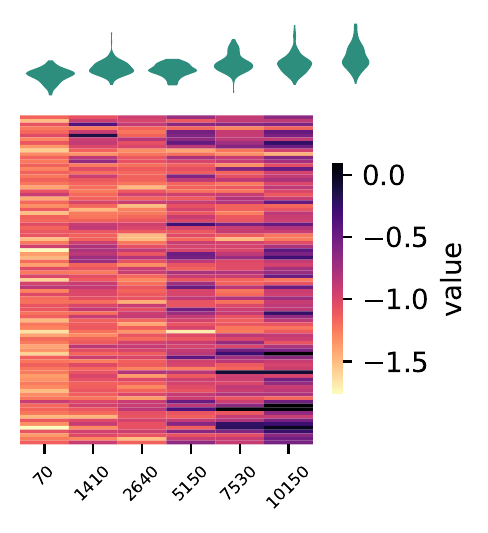

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import gridspec

pdf_file = "yeast_evolved_kGain_vs_population_with_generation_as_hue_heatmap.pdf"

pivot_table_median = all_mutation.pivot_table(
    index='population_name',
    columns='generation_number',
    aggfunc='median',
    values='kGain_evolved_genome'
)

ordered_cols = sorted(
    pivot_table_median.columns,
    key=lambda x: pd.to_numeric(x, errors='coerce') if pd.notna(pd.to_numeric(x, errors='coerce')) else x
)
pivot_table_median = pivot_table_median[ordered_cols]

plot_df = pivot_table_median.copy()
plot_df.columns = plot_df.columns.astype(str)
melted_df = plot_df.reset_index(drop=True).melt(var_name='generation_number', value_name='kGain_evolved_genome').dropna()

fig = plt.figure(figsize=(6/2.54, 7/2.54))
gs = gridspec.GridSpec(2, 1, height_ratios=[1.2, 5], hspace=0.08)

ax_top = fig.add_subplot(gs[0])
sns.violinplot(
    data=melted_df,
    x='generation_number',
    y='kGain_evolved_genome',
    inner=None,
    color=sns.color_palette('viridis', 8)[4],
    linewidth=0,
    cut=0,
    ax=ax_top
)
ax_top.set_xlabel('')
ax_top.set_ylabel('')
ax_top.set_xticks([])
ax_top.tick_params(left=False, labelleft=False, bottom=False)
for spine in ax_top.spines.values():
    spine.set_visible(False)

ax_heat = fig.add_subplot(gs[1])
sns.heatmap(
    plot_df,
    cmap='magma_r',
    cbar_kws={'label': 'value', 'shrink': 0.7},
    xticklabels=True,
    yticklabels=False,
    ax=ax_heat
)
ax_heat.set_xlabel('')
ax_heat.set_ylabel('')
ax_heat.tick_params(axis='x', rotation=45, labelsize=6)

fig.savefig(pdf_file, format='pdf', bbox_inches='tight')
plt.close(fig)

pages = convert_from_path(pdf_file, dpi=200)
display(pages[0])
